# **Task 1 | MLP**
---


### Rock, Paper, Scissors dataset

#### **Definition :**
The Rock, Paper, Scissors dataset is a collection of images depicting hands playing the classic hand game, created for image classification and computer vision machine learning tasks.

* Link Dataset : https://www.tensorflow.org/datasets/catalog/rock_paper_scissors

* **Images:** RGB images with a fixed resolution of $300 \times 300 \text{ pixels}$ (shape 300, 300, 3).

* **Labels:** Three distinct classes (num_classes=3) corresponding to rock, paper, and scissors. (0-> Rock , 1-> Paper , 2-> Scissors)

* Split Traain set  **90%** and test set **10%**

* Using 5 optimizer **(SGD , SGD_Momentum , Adagrad , RMS PROP , Adam )**

* Build 5 **MLP** models with 5 optimizer

In [2]:
import logging
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import tensorflow_datasets as tfds
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

print("Pandas Version:", pd.__version__)
print("Scikit-Learn Version:", sklearn.__version__)
print("Matplotlib Version:", plt.__import_lib__ if hasattr(plt, '__import_lib__') else "Successfully Imported")
print("TensorFlow Version:", tf.__version__)
print("TensorFlow Dataset Version:", tfds.__version__)
print("GPU Devices:", tf.config.list_physical_devices('GPU'))

Pandas Version: 2.3.3
Scikit-Learn Version: 1.7.2
Matplotlib Version: Successfully Imported
TensorFlow Version: 2.10.0
TensorFlow Dataset Version: 4.8.3
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## **Data Collection**

In [3]:
# 1. Load the dataset (splits into train and test)
(train_ds, test_ds), info = tfds.load(
    "rock_paper_scissors",
    split=["train[:90%]+test[:90%]", "train[90%:]+test[90%:]"],
    as_supervised=True,  # Yields (image, label) pairs
    with_info=True       # Provides dataset metadata
)

# 2. Print Dataset Overview
print("=== Dataset Information ===")
print("Number of Classes:", info.features["label"].num_classes)
print("Class Labels:", info.features["label"].names)
print("Training Examples:", info.splits["train"].num_examples)
print("Testing Examples:", info.splits["test"].num_examples)

# 3. Inspect Image & Label Shapes
for image, label in train_ds.take(1):
    print("\n=== Sample Image Batch Info ===")
    print("Single Image Shape:", image.shape)
    print("Single Image Data Type:", image.dtype)
    print("Label Value:", label.numpy(), f"({info.features['label'].names[label.numpy()]})")

=== Dataset Information ===
Number of Classes: 3
Class Labels: ['rock', 'paper', 'scissors']
Training Examples: 2520
Testing Examples: 372

=== Sample Image Batch Info ===
Single Image Shape: (300, 300, 3)
Single Image Data Type: <dtype: 'uint8'>
Label Value: 2 (scissors)


## **Data Analysis**

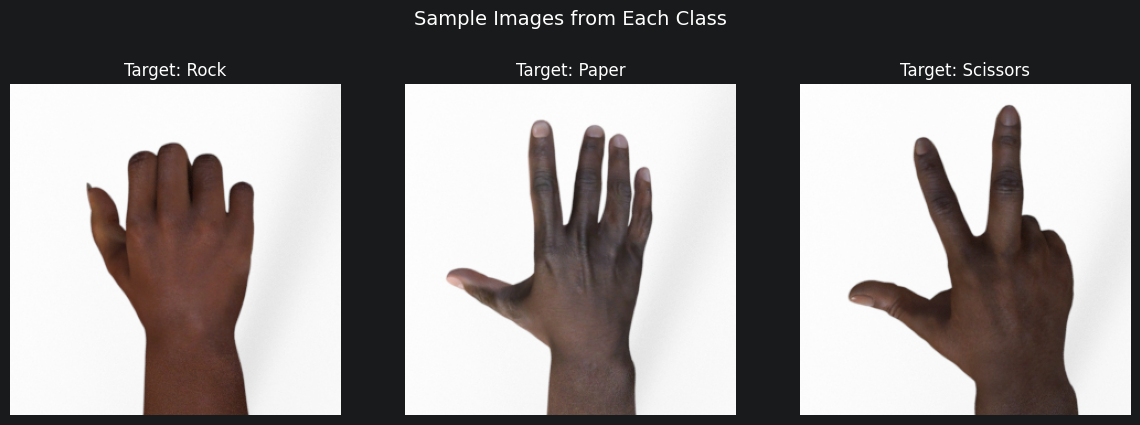

In [4]:
# Get class names ['paper', 'rock', 'scissors']
class_names = info.features["label"].names

# ---------------------------------------------------
# 1. Plot Sample Images of the 3 Targets
# ---------------------------------------------------
samples = {}
for image, label in train_ds:
    lbl = label.numpy()
    if lbl not in samples:
        samples[lbl] = image.numpy()
    if len(samples) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, label_idx in enumerate(sorted(samples.keys())):
    axes[idx].imshow(samples[label_idx])
    axes[idx].set_title(f"Target: {class_names[label_idx].capitalize()}")
    axes[idx].axis("off")

plt.suptitle("Sample Images from Each Class", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

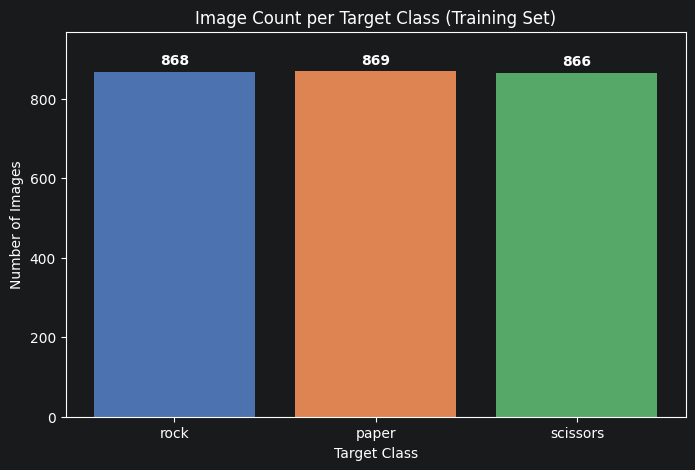

In [5]:
# ---------------------------------------------------
# 2. Chart Number of Images for the 3 Targets
# ---------------------------------------------------
# Count images per target class in training set
class_counts = {name: 0 for name in class_names}
for _, label in train_ds:
    class_counts[class_names[label.numpy()]] += 1

# Plot Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=['#4C72B0', '#DD8452', '#55A868'])
plt.title("Image Count per Target Class (Training Set)")
plt.xlabel("Target Class")
plt.ylabel("Number of Images")

# Add count labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{yval}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, max(class_counts.values()) + 100)
plt.show()

## **Data Preprocessing**

### Target Classis 

In [8]:
# Define target dimensions
IMG_SIZE = (128,128)
NUM_CLASSES = 3

# Preprocessing function: resizes image and scales pixel values from [0, 255] to [0.0, 1.0]
def preprocess_image(image, label):
    image = tf.image.resize(image,IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image , label

In [9]:
# Apply resizing and normalization to train and test sets
train_ds_processed = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_processed = test_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

# Verify output shapes and value ranges
for img, lbl in train_ds_processed.take(1):
    print("Resized Image Shape:", img.shape)
    print("Min Pixel Value:", tf.reduce_min(img).numpy())
    print("Max Pixel Value:", tf.reduce_max(img).numpy())

Resized Image Shape: (128, 128, 3)
Min Pixel Value: 0.054945044
Max Pixel Value: 0.99904835


In [10]:
# Print example counts to verify the split
total_examples = info.splits["train"].num_examples + info.splits["test"].num_examples
print("Total Dataset Examples:", total_examples)
print(f"90% Training Set Examples: {len(train_ds)}")
print(f"10% Testing Set Examples: {len(test_ds)}")

Total Dataset Examples: 2892
90% Training Set Examples: 2603
10% Testing Set Examples: 289


### Data Augmentation

In [11]:
# Hide non-critical TensorFlow warnings
tf.get_logger().setLevel(logging.ERROR)

In [12]:
# Define Data Augmentation operations
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),  # Rotates image up to +/- 10%
    layers.RandomZoom(0.1),      # Zooms image up to +/- 10%
], name="data_augmentation")

# Function to apply augmentation only to training images
def augment_train(image, label):
    image = data_augmentation(image)
    return image, label

# Apply data augmentation to the training set
train_ds_augmented = train_ds_processed.map(
    augment_train, 
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Data Augmentation applied successfully!")

Data Augmentation applied successfully!


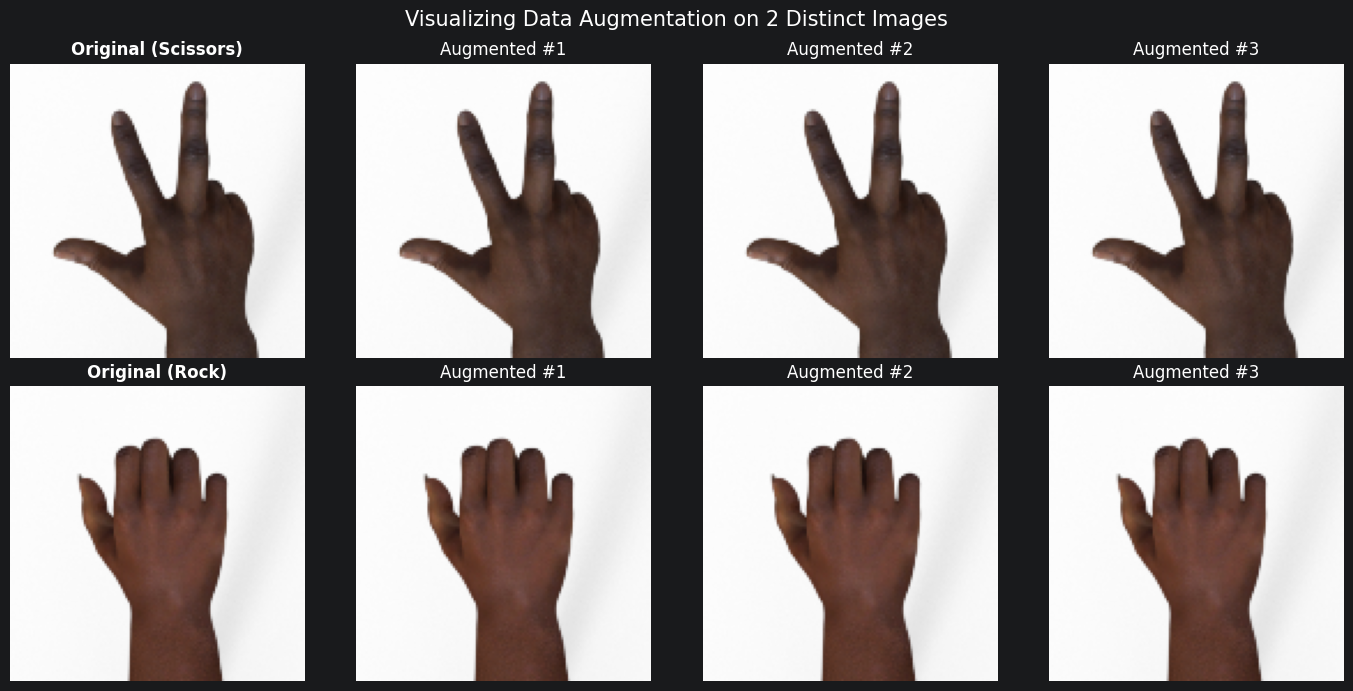

In [13]:
# 1. Grab 2 distinct images from the dataset
sample_images = []
sample_labels = []

for img, lbl in train_ds_processed.take(10):
    # Get class index from one-hot encoded vector
    class_idx = tf.argmax(lbl).numpy()
    if class_idx not in [l for l in sample_labels]:
        sample_images.append(img)
        sample_labels.append(class_idx)
    if len(sample_images) == 2:
        break

# 2. Plot original image + 3 augmented versions for each of the 2 images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row_idx, (img, label_idx) in enumerate(zip(sample_images, sample_labels)):
    class_name = info.features["label"].names[label_idx].capitalize()
    
    # Original Image (Column 0)
    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(f"Original ({class_name})", fontweight="bold")
    axes[row_idx, 0].axis("off")
    
    # 3 Augmented Variations (Columns 1, 2, 3)
    for col_idx in range(1, 4):
        augmented_img = data_augmentation(tf.expand_dims(img, 0))[0]
        axes[row_idx, col_idx].imshow(augmented_img)
        axes[row_idx, col_idx].set_title(f"Augmented #{col_idx}")
        axes[row_idx, col_idx].axis("off")

plt.suptitle("Visualizing Data Augmentation on 2 Distinct Images", fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

### Batchs

In [21]:
BATCH_SIZE = 32

# 1. Prepare Training Pipeline (Augment -> Shuffle -> Batch -> Prefetch)
train_pipeline = (
    train_ds_augmented
    .shuffle(buffer_size=1000)
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

# 2. Prepare Testing Pipeline (Batch -> Prefetch)
# Note: Testing data is NOT shuffled or augmented
test_pipeline = (
    test_ds_processed
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

# 3. Verify Batch Shapes
for images_batch, labels_batch in train_pipeline.take(1):
    print("=== Pipeline Batch Summary ===")
    print("Batch Images Shape:", images_batch.shape)  # Should be (32, 150, 150, 3)
    print("Batch Labels Shape:", labels_batch.shape)  # Should be (32, 3)

=== Pipeline Batch Summary ===
Batch Images Shape: (32, 128, 128, 3)
Batch Labels Shape: (32, 3)


## **Selectting Models**

### MLP

In [28]:
def build_mlp():
    model = models.Sequential([
        layers.Flatten(input_shape=(128, 128, 3)),

        layers.Dense(512, activation='relu'),
        # Increased from 0.2 to 0.5 to heavily penalize memorization
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        # Added a second dropout layer to force the 256-layer to generalize
        layers.Dropout(0.3),

        layers.Dense(3, activation='softmax')
    ])
    return model

# Build the model
mlp_model = build_mlp()

# Call summary
mlp_model.summary()

Model: "sequential_23"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_23 (Flatten)        (None, 49152)             0         
                                                                 
 dense_69 (Dense)            (None, 512)               25166336  
                                                                 
 dropout_23 (Dropout)        (None, 512)               0         
                                                                 
 dense_70 (Dense)            (None, 256)               131328    
                                                                 
 dropout_24 (Dropout)        (None, 256)               0         
                                                                 
 dense_71 (Dense)            (None, 3)                 771       
                                                                 
Total params: 25,298,435
Trainable params: 25,298,435

In [29]:
# 1. MLP Model with SGD
mlp_sgd = build_mlp()
mlp_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. MLP Model with SGD + Momentum
mlp_sgd_momentum = build_mlp()
mlp_sgd_momentum.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. MLP Model with Adagrad
mlp_adagrad = build_mlp()
mlp_adagrad.compile(
    optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. MLP Model with RMSprop
mlp_rmsprop = build_mlp()
mlp_rmsprop.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. MLP Model with Adam
mlp_adam = build_mlp()
mlp_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("All 5 MLP models built and compiled successfully using your custom structure!")

All 5 MLP models built and compiled successfully using your custom structure!


In [30]:
# Training all 5 MLP models and recording their training and test performance

optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.0001),
    'SGD+Momentum': tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9),
    'Adagrad': tf.keras.optimizers.Adagrad(learning_rate=0.0001),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.0001)
}

results = []
histories = {}

# 2. Define the Early Stopping callback here
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,                  # Stops if no improvement after 3 epochs
    restore_best_weights=True    # Rolls back to the best performing epoch
)

# Map our pre-compiled or dictionary definitions directly, or rebuild inside the loop using your function
for name, optimizer in optimizers.items():
    print(f"\n--- Training MLP with {name} ---")

    # Build fresh model structure
    model = build_mlp()

    # Compile with the specific optimizer (using categorical_crossentropy since labels are one-hot encoded)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train for 10 epochs using our training pipeline and validation dataset
    history = model.fit(
        train_pipeline,
        validation_data=test_pipeline,  # Change to val_ds if you have a separate validation set
        epochs=15,
        verbose=1,
        callbacks = [early_stop]
    )

    # Evaluate final performance on the test pipeline
    test_loss, test_acc = model.evaluate(test_pipeline, verbose=0)

    # Save history and results
    histories[name] = history.history
    results.append({
        'Optimizer': name,
        'Train Loss': history.history['loss'][-1],
        'Train Acc': history.history['accuracy'][-1],
        'Val Loss': history.history['val_loss'][-1],
        'Val Acc': history.history['val_accuracy'][-1],
        'Test Loss': test_loss,
        'Test Acc': test_acc
    })

print("\nAll models have finished training!")

results_df = pd.DataFrame(results)
best_summary = results_df.sort_values(by='Test Acc', ascending=False).reset_index(drop=True)
best_summary.insert(0, 'Rank', range(1, len(best_summary) + 1))
print("\n=== Final Model Accuracy Ranking ===")
print(best_summary[['Rank', 'Optimizer', 'Train Acc', 'Val Acc', 'Test Acc']].to_string(index=False))


--- Training MLP with SGD ---
Epoch 1/15
82/82 [==============================] - 2s 20ms/step - loss: 1.2868 - accuracy: 0.3780 - val_loss: 0.9716 - val_accuracy: 0.6747
Epoch 2/15
82/82 [==============================] - 1s 14ms/step - loss: 1.0713 - accuracy: 0.4564 - val_loss: 0.9247 - val_accuracy: 0.6505
Epoch 3/15
82/82 [==============================] - 1s 14ms/step - loss: 0.9961 - accuracy: 0.5052 - val_loss: 0.9227 - val_accuracy: 0.5882
Epoch 4/15
82/82 [==============================] - 1s 15ms/step - loss: 0.9578 - accuracy: 0.5317 - val_loss: 0.8610 - val_accuracy: 0.7197
Epoch 5/15
82/82 [==============================] - 1s 14ms/step - loss: 0.9098 - accuracy: 0.5862 - val_loss: 0.9057 - val_accuracy: 0.5848
Epoch 6/15
82/82 [==============================] - 1s 14ms/step - loss: 0.8845 - accuracy: 0.5955 - val_loss: 0.8098 - val_accuracy: 0.7024
Epoch 7/15
82/82 [==============================] - 1s 15ms/step - loss: 0.8559 - accuracy: 0.6439 - val_loss: 0.7999 - val


--- Model Performance Summary ---
   Optimizer  Train Loss  Train Acc  Val Loss  Val Acc  Test Loss  Test Acc
         SGD    0.855949   0.643872  0.799932 0.615917   0.861041  0.719723
SGD+Momentum    0.685458   0.736074  0.580943 0.861592   0.652480  0.882353
     Adagrad    0.637414   0.772570  0.676010 0.660900   0.632157  0.854671
     RMSProp    1.057539   0.388782  1.113754 0.408305   1.049113  0.449827
        Adam    1.098639   0.332693  1.098597 0.339100   1.098586  0.339100


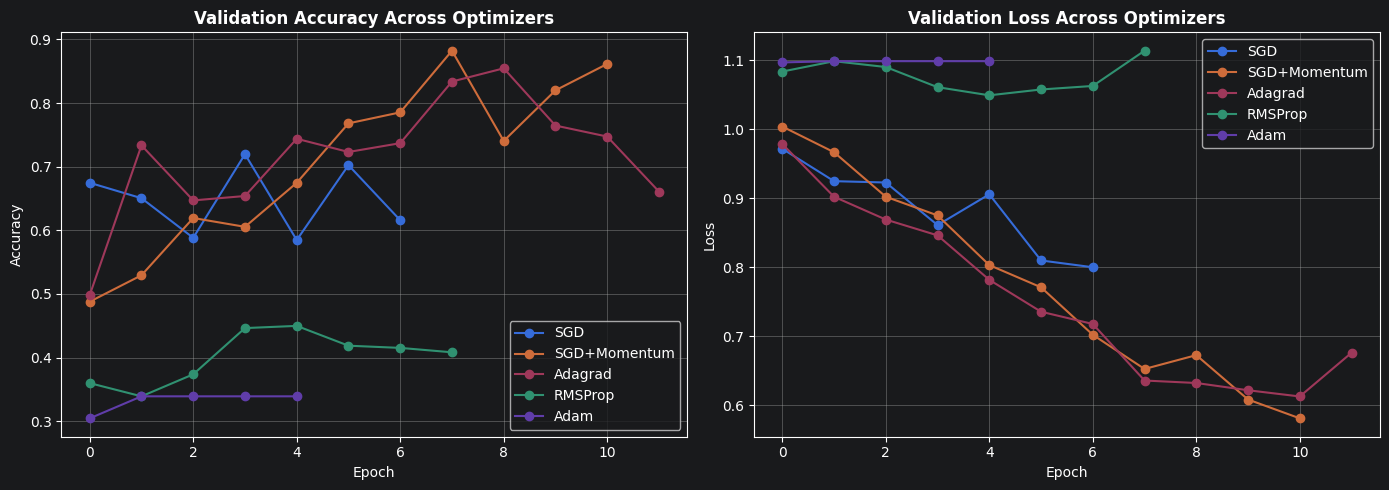

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a clean summary table of the results
results_df = pd.DataFrame(results)
print("\n--- Model Performance Summary ---")
print(results_df.to_string(index=False))

# 2. Plot Validation Accuracy and Loss Comparison
plt.figure(figsize=(14, 5))

# Plot Validation Accuracy
plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history['val_accuracy'], marker='o', label=f"{name}")
plt.title('Validation Accuracy Across Optimizers', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history['val_loss'], marker='o', label=f"{name}")
plt.title('Validation Loss Across Optimizers', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


=== NEW Model Accuracy Ranking ===
 Rank    Optimizer  Train Acc  Val Acc  Test Acc
    1 SGD+Momentum   0.736074 0.861592  0.882353
    2      Adagrad   0.772570 0.660900  0.854671
    3          SGD   0.643872 0.615917  0.719723
    4      RMSProp   0.388782 0.408305  0.449827
    5         Adam   0.332693 0.339100  0.339100


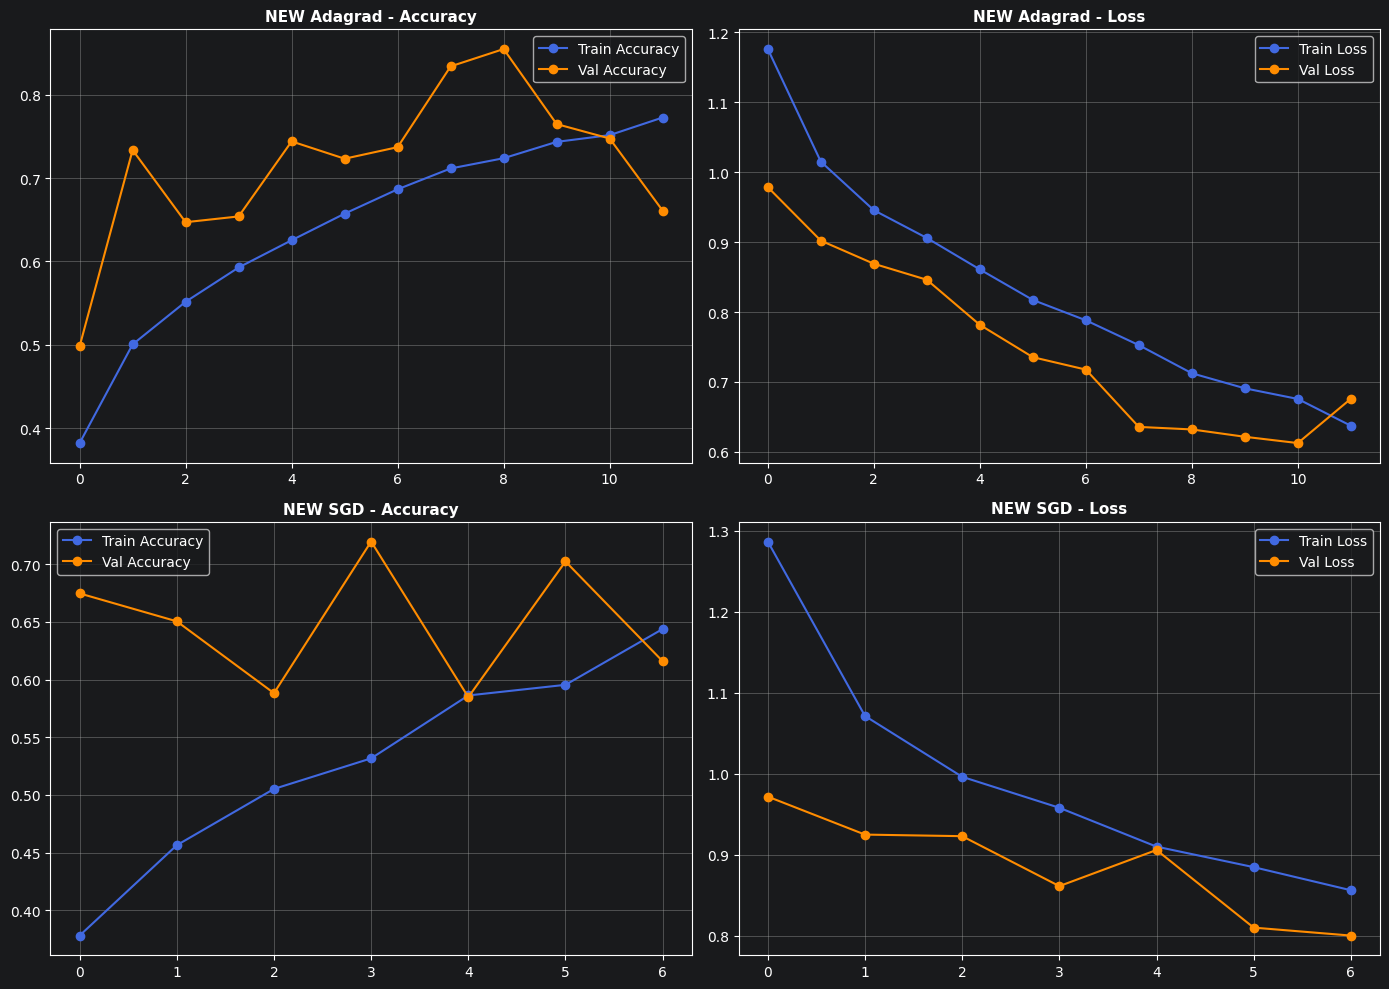

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Print the new ranked results
results_df = pd.DataFrame(results)
best_summary = results_df.sort_values(by='Test Acc', ascending=False).reset_index(drop=True)
best_summary.insert(0, 'Rank', range(1, len(best_summary) + 1))

print("\n=== NEW Model Accuracy Ranking ===")
print(best_summary[['Rank', 'Optimizer', 'Train Acc', 'Val Acc', 'Test Acc']].to_string(index=False))

# 2. Plot the new graphs to check for stability
plt.figure(figsize=(14, 10))

# Plot Adagrad
plt.subplot(2, 2, 1)
plt.plot(histories['Adagrad']['accuracy'], label='Train Accuracy', marker='o', color='royalblue')
plt.plot(histories['Adagrad']['val_accuracy'], label='Val Accuracy', marker='o', color='darkorange')
plt.title('NEW Adagrad - Accuracy', fontsize=11, fontweight='bold')
plt.legend(); plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(histories['Adagrad']['loss'], label='Train Loss', marker='o', color='royalblue')
plt.plot(histories['Adagrad']['val_loss'], label='Val Loss', marker='o', color='darkorange')
plt.title('NEW Adagrad - Loss', fontsize=11, fontweight='bold')
plt.legend(); plt.grid(True)

# Plot SGD
plt.subplot(2, 2, 3)
plt.plot(histories['SGD']['accuracy'], label='Train Accuracy', marker='o', color='royalblue')
plt.plot(histories['SGD']['val_accuracy'], label='Val Accuracy', marker='o', color='darkorange')
plt.title('NEW SGD - Accuracy', fontsize=11, fontweight='bold')
plt.legend(); plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(histories['SGD']['loss'], label='Train Loss', marker='o', color='royalblue')
plt.plot(histories['SGD']['val_loss'], label='Val Loss', marker='o', color='darkorange')
plt.title('NEW SGD - Loss', fontsize=11, fontweight='bold')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# 1. Sort the results dataframe by Test Accuracy (or Val Accuracy) in descending order
best_summary = results_df.sort_values(by='Test Acc', ascending=False).reset_index(drop=True)

# 2. Add a rank column to clearly show the hierarchy
best_summary.insert(0, 'Rank', range(1, len(best_summary) + 1))

# 3. Print the sorted summary table
print("\n=== Model Accuracy Ranking Summary ===")
print(best_summary[['Rank', 'Optimizer', 'Train Acc', 'Val Acc', 'Test Acc']].to_string(index=False))


=== Model Accuracy Ranking Summary ===
 Rank    Optimizer  Train Acc  Val Acc  Test Acc
    1          SGD   0.810987 0.906574  0.906574
    2      Adagrad   0.812140 0.861592  0.861592
    3         Adam   0.566654 0.660900  0.660900
    4 SGD+Momentum   0.529773 0.643599  0.643599
    5      RMSProp   0.323473 0.332180  0.332180
